<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB
None
              stars          cool        useful         funny
count  10000.000000  10000.000000  10000.000000  10000.000000
mean       3.777500      0.876800      1.409300      0.701300
std        1.214636      2.067861      2.336647      1.907942
min        1.000000      0.000000      0.000000      0.000000
25%        3.000000      0.000000

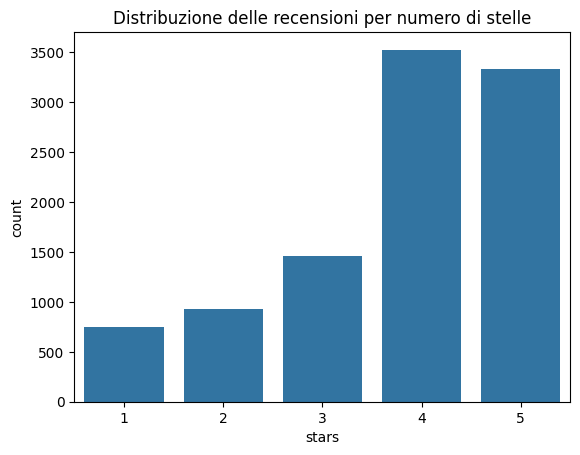

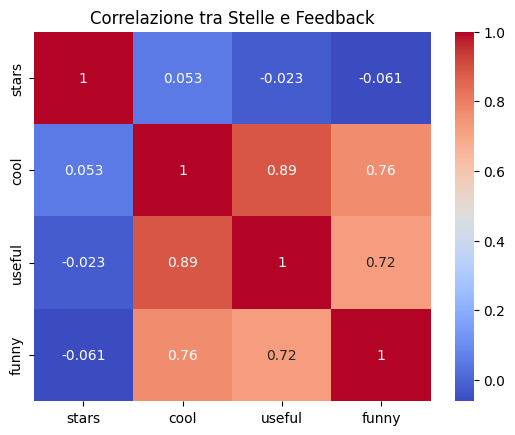

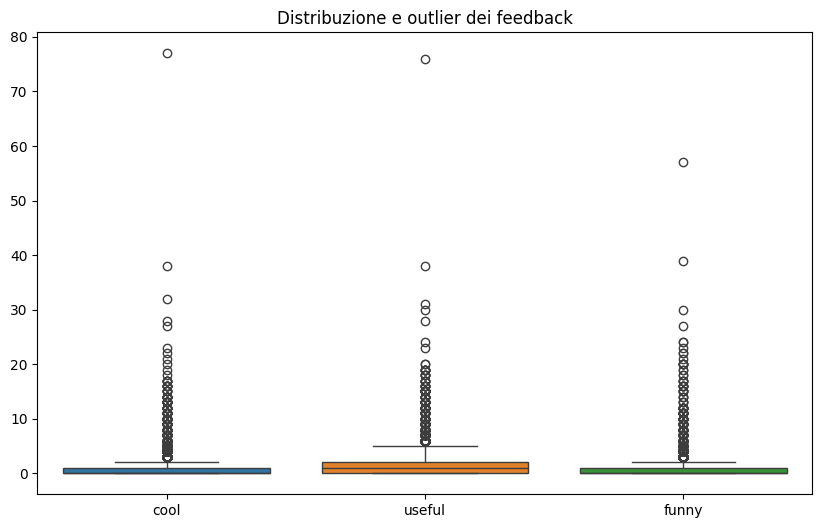

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Carico il dataset
df=pd.read_csv('yelp.csv')

print(df.info())

#Statistiche descrittive
print(df[['stars','cool','useful','funny']].describe())

#Distribuzione delle stelle
sns.countplot(data=df,x='stars')
plt.title("Distribuzione delle recensioni per numero di stelle")
plt.show()

#Esplorazione correlazione
stars_corr=df[['stars','cool','useful','funny']].corr()

'''Mostra che la correlazione è bassa, quindi si avverte al lettore che le feature sono deboli'''
sns.heatmap(stars_corr,annot=True,cmap='coolwarm')
plt.title("Correlazione tra Stelle e Feedback")
plt.show()

#Boxplot per vedere gli outlier nei feedback
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['cool','useful','funny']])
plt.title("Distribuzione e outlier dei feedback")
plt.show()

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

X=df[['cool','useful','funny']]
y=df['stars']


def evaluate_linear_regression(X_data,y_data):
    #Split 80/20
    X_train,X_test,y_train,y_test=train_test_split(X_data,y_data,test_size=0.2,random_state=1)
    linreg=LinearRegression()
    linreg.fit(X_train,y_train)

    #Previsione e calcolo RMSE
    y_pred=linreg.predict(X_test)
    return np.sqrt(metrics.mean_squared_error(y_test,y_pred))

rmse_all=evaluate_linear_regression(X,y)
print(f"RMSE con tutte le feature: {rmse_all:.4f}")

#Test con singole feature per vedere quale correla meglio
rmse_cool=evaluate_linear_regression(df[['cool']],y)
rmse_useful=evaluate_linear_regression(df[['useful']],y)
rmse_funny=evaluate_linear_regression(df[['funny']],y)
print(f"RMSE solo con cool: {rmse_cool:.3f}")
print(f"RMSE solo con useful: {rmse_useful:.3f}")
print(f"RMSE solo con funny: {rmse_funny:.3f}")

RMSE con tutte le feature: 1.1837
RMSE solo con cool: 1.210
RMSE solo con useful: 1.211
RMSE solo con funny: 1.210


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix

#Test senza bilanciamento classi
'''Dato che le SVM sono sensibili alla scala dobbiamo standardizzare i dati, eseguiamo un preprocessing'''
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_train_s,X_test_s,y_train_s,y_test_s=train_test_split(X_scaled,y,test_size=0.2,random_state=1)

model_svm=SVC()
model_svm.fit(X_train_s,y_train_s)
y_pred_svm=model_svm.predict(X_test_s)
accuracy=accuracy_score(y_test_s,y_pred_svm)
print(f"Accuratezza SVM: {accuracy:.2%}")

Accuratezza SVM: 35.25%


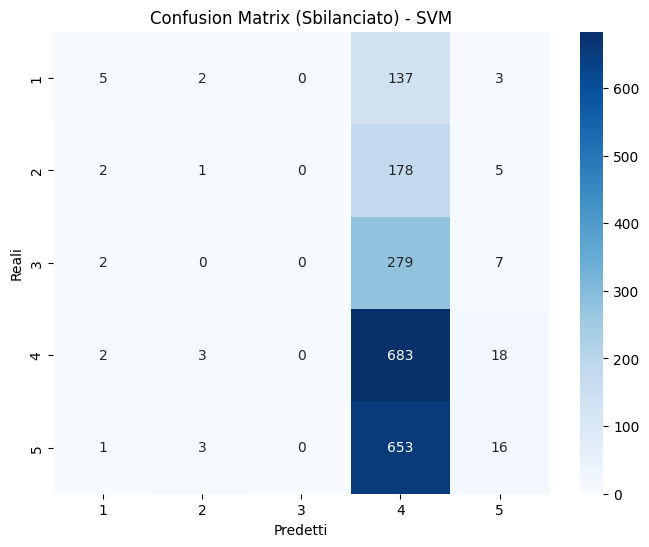

In [7]:
cm=confusion_matrix(y_test_s,y_pred_svm)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=[1,2,3,4,5],yticklabels=[1,2,3,4,5])

plt.xlabel("Predetti")
plt.ylabel("Reali")
plt.title("Confusion Matrix (Sbilanciato) - SVM")
plt.show()

In [8]:
#Test bilanciando le classi
'''Utilizzo di balanced per rendere il modello capace di vedere tutte le classi'''
model_svm_balanced=SVC(class_weight='balanced')
model_svm_balanced.fit(X_train_s,y_train_s)

y_pred_svm_balanced=model_svm_balanced.predict(X_test_s)
accuracy=accuracy_score(y_test_s,y_pred_svm_balanced)
print(f"Accuratezza SVM: {accuracy:.2%}")
#print("Report di classificazione: ")
#print(classification_report(y_test_s,y_pred_svm))

Accuratezza SVM: 27.45%


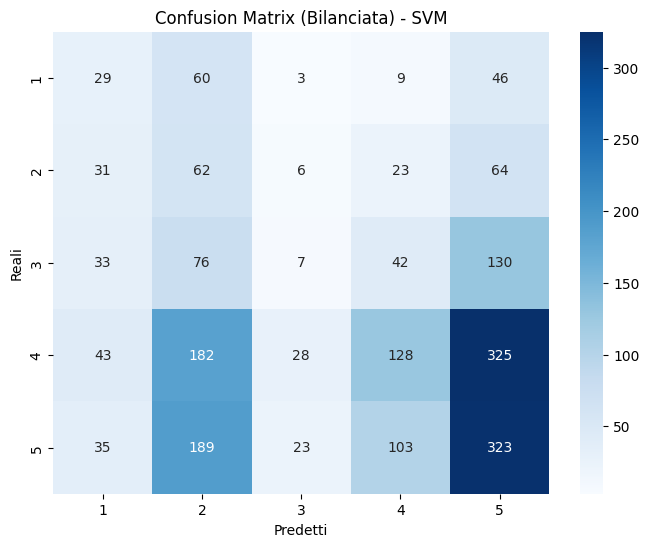

In [9]:
cm_balanced=confusion_matrix(y_test_s,y_pred_svm_balanced)

plt.figure(figsize=(8,6))
sns.heatmap(cm_balanced,annot=True,fmt='d',cmap='Blues',xticklabels=[1,2,3,4,5],yticklabels=[1,2,3,4,5])

plt.xlabel("Predetti")
plt.ylabel("Reali")
plt.title("Confusion Matrix (Bilanciata) - SVM")
plt.show()